# Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
import h5py
import astropy

In [2]:

import matplotlib
from matplotlib.image import NonUniformImage
from scipy.stats import gmean
# imports 
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity
from bbhx.waveformbuild import BBHWaveformFD
from eryn.prior import uniform_dist
from itertools import chain, repeat
import random
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.cosmology import z_at_value, Planck18, Planck13

# imports
from lisatools.sensitivity import AET1SensitivityMatrix
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer
import math
import pickle

No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy
No CuPy or GPU response available.


# BH Data

In [4]:
df = pd.read_csv("jillian.txt", sep="\t", dtype={"time (Gyr)": float, "mass ratio": float, "redshift": float, "total BH mass (Msun)": float})

In [5]:
time= df['time (Gyr)']
ratio= df['mass ratio']
z=np.array(df['redshift'])
M=df['total BH mass (Msun)']

In [6]:
m1=np.array(M/(1+ratio))

In [7]:
m2=np.array(ratio*m1)

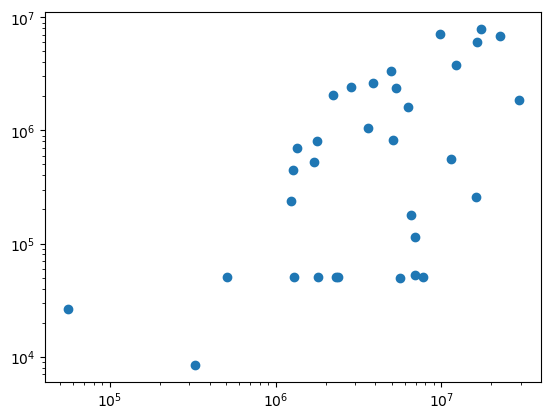

In [8]:
plt.loglog(m1,m2,'o')

In [9]:
cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089, Tcmb0=2.725)
d_l=np.array(cosmo.luminosity_distance(z).value*1e6*PC_SI)

# Functions

## SNR Calculators

In [10]:
arr_size = len(m1)
tdi_wave_gen = BBHWaveformFD()

def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

def SNR_calc_stoch(m1 = m1, m2 = m2, dist = d_l, chi1 = np.full(arr_size, 0.5),
             chi2 = np.full(arr_size, 0.7), phi_ref = np.full(arr_size, 0.6),
             f_ref = np.full(arr_size, 0.0), inc = np.full(arr_size, np.pi / 8),
             lam = np.full(arr_size, 0.5), beta = np.full(arr_size, -0.7),
             psi = np.full(arr_size, np.pi / 4), t_ref = np.full(arr_size, 0.5 * YRSID_SI),
             num_elements = len(m1),obs=1,z=z,t_obs_end=1):
    length = 1024

    # Setup data holders
    Tobs = YRSID_SI / 12*obs    # 1 month
    dt = 10.0  # sec
    N = int(Tobs / dt)
    Tobs = N * dt

    freqs = np.fft.rfftfreq(N, dt)
    freqs=freqs[freqs>=10**(-4)]
    
    SNR_new = []

    for i in range(num_elements):
        AET_gen = tdi_wave_gen(
            m1[i],
            m2[i], 
            chi1[i],
            chi2[i],
            dist[i], 
            phi_ref[i],
            f_ref[i], 
            inc[i],
            lam[i],
            beta[i],
            psi[i],
            t_ref[i],
            t_obs_start=0,
            t_obs_end=t_obs_end,         
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        )
     
        data = DataResidualArray(AET_gen[0], f_arr=freqs)
        sens_mat = AET1SensitivityMatrix(data.f_arr,stochastic_params=(4.0 * YRSID_SI,))
        analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
        snr = analysis.snr()
        SNR_new.append(snr)

    return SNR_new

## Parameter Generator

In [11]:
def draw_params(m1 = m1, 
                m2 = m2, dist = d_l,z=z,n=1): 
                
    arr_size=len(m1)*n
    
    znew = np.array(list(chain.from_iterable(repeat(x, n) for x in z)))
    m1new = np.array(list(chain.from_iterable(repeat(x, n) for x in m1)))*(znew+1)
    m2new = np.array(list(chain.from_iterable(repeat(x, n) for x in m2)))*(znew+1)
    distnew = np.array(list(chain.from_iterable(repeat(x, n) for x in dist)))
        

    # chi1 = np.full(arr_size, spin)
    # chi2 = np.full(arr_size, spin)
    
    phi_ref =  uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    f_ref = np.full(arr_size, 0)
    inc = np.arccos(uniform_dist(-1.0, 1.0).rvs(arr_size))
    lam = uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    beta = np.arcsin(uniform_dist(-1.0, 1.0).rvs(arr_size))
    psi = uniform_dist(0.0, np.pi).rvs(arr_size)
    t_ref = np.full(arr_size, 1e6)

    result={
         'm1'  : m1new,
         'm2'  : m2new,
         'z'   : znew,
        'dist' : distnew,
        # 'chi1':chi1,
        # 'chi2':chi2,
        'phi_ref': phi_ref,
        'f_ref': f_ref,
        'inc' : inc,
        'lam' : lam,
        'beta': beta,
        'psi' : psi,
        't_ref': t_ref,
        'num_elements':arr_size
    }
     
    return result

## Plotters

In [12]:
def avg_hist(x,y,z, bins=(20,20), c1='YlOrRd', c2= 'YlGnBu',  labelx=None, labely=None,
            labelz=None, norm1=matplotlib.colors.LogNorm(), logweight=True, 
            norm2=None, vmin=None,vmax=None):
 #            norm2=matplotlib.colors.LogNorm(vmin=None, vmax=None) ):
    z_mask=((~np.isnan(z))&(~np.isnan(x))&(~np.isnan(y)))
    x=x[z_mask]
    y=y[z_mask]
    z=z[z_mask]
    H_num, xedges, yedges = np.histogram2d(x, y, bins=bins)
    if logweight:
        z=np.log10(z)
    H_z, xedges, yedges = np.histogram2d(x,y, bins=(xedges, yedges), weights=z)
    H_num=H_num.T
    H_z=H_z.T
    plt.figure(figsize=(15,10))
    plt.subplot(2, 1, 1)
    plt.imshow(H_num, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
           cmap= c1, norm=norm1)
 
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label='Numbers')

    plt.subplot(2,1,2)
    plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
               cmap=c2, norm=norm2, vmax=vmax,vmin=vmin)
    #print(np.min(H_z/H_num), np.max(H_z/H_num))
    #print(H_z/H_num)
   
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label=labelz)
   
    
    plt.tight_layout()
    plt.gca().set_aspect('equal')


In [13]:
def y_mean_plotter(x, y, ybins=10, color='orange', marker='o', plt_type=True, xgmean=True, ygmean=True, plot=True):
    
    start = min(y)
    stop = max(y)
    
    if ygmean:
        values = np.logspace(np.log10(start), np.log10(stop), ybins)
    else:
        values = np.linspace(start, stop, ybins)
    x_mean = []
    y_mean = []

    for i in range(len(values)-1):
        mask_y = ((y > values[i]) & (y < values[i+1]) & (~np.isnan(x)))
        y_slice = values[i:i+2]
        if ygmean:
            y_mean.append(gmean(y_slice))
        else:
            y_mean.append(np.mean(y_slice))
        if xgmean:   
            x_mean.append(gmean(x[mask_y]))
        else:
            x_mean.append(np.mean(x[mask_y]))
        if plot:
            if plt_type:
                plt.plot(x_mean, y_mean, color=color, marker=marker)
            else:
                plt.scatter(x_mean, y_mean, color=color, marker=marker)

    return x_mean, y_mean

In [14]:
def x_mean_plotter(x, y, xbins=10, color='red', marker='o', plt_type=True, xgmean=True, ygmean=True, plot=True, label=None):
    
    start = min(x)
    stop = max(x)
    
    if xgmean:
        values = np.logspace(np.log10(start), np.log10(stop), xbins)
    else:
        values = np.linspace(start, stop, xbins)
    x_mean = []
    y_mean = []

    for i in range(len(values)-1):
        mask_x = ((x > values[i]) & (x < values[i+1]) & (~np.isnan(y)))
        x_slice = values[i:i+2]
        if xgmean:
            x_mean.append(gmean(x_slice))
        else:
            x_mean.append(np.mean(x_slice))
        if ygmean:   
            y_mean.append(gmean(y[mask_x]))
        else:
            y_mean.append(np.mean(y[mask_x]))
        if plot:
            if plt_type:
                plt.plot(x_mean, y_mean, color=color, marker=marker)
            else:
                plt.scatter(x_mean, y_mean, color=color, marker=marker)

    return x_mean, y_mean


# Analysis


In [19]:
pop_J=draw_params(n=10)

In [20]:
snr_j=SNR_calc_stoch(**pop_J,chi1 = np.full(arr_size*10,.8),chi2 = np.full(arr_size*10, 0.8))

In [47]:
M_1=np.array(list(chain.from_iterable(repeat(x, 10) for x in m1)))
M_2=np.array(list(chain.from_iterable(repeat(x, 10) for x in m2)))
Z=np.array(list(chain.from_iterable(repeat(x, 10) for x in z)))


Text(0, 0.5, 'log(SNR)')

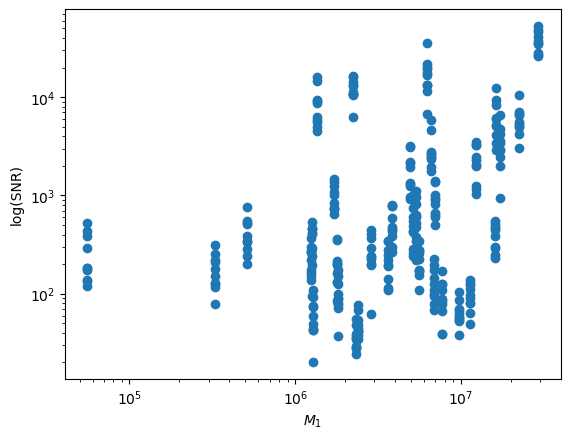

In [48]:
plt.loglog(M_1,snr_j,'o')
plt.xlabel('$M_1$')
plt.ylabel('log(SNR)')

Text(0, 0.5, '$SNR$')

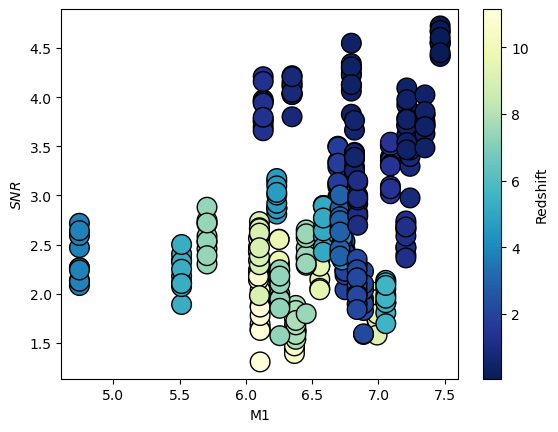

In [49]:

sc=plt.scatter(
      # X-axis
      # Y-axis
    np.log10(M_1),
    np.log10(snr_j),
      c=Z,  # Color by redshift
    cmap="YlGnBu_r",  # Choose a colormap (e.g., 'viridis', 'plasma', 'coolwarm')
    edgecolors="k", 
    alpha=1,s=200
)
cbar=plt.colorbar(sc)
cbar.set_label("Redshift")
plt.xlabel('M1')
plt.ylabel('$SNR'
'$')

In [50]:
# from lisatools.sources import EMRICalculationController

In [51]:
# from lisatools.sources import BBHCalculationController

In [52]:
# controller = BBHCalculationController(psd='lisatools.sensitivity.A1TDISens') 
# snr_bbh = controller.get_snr()

/tmp/ipykernel_43163/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


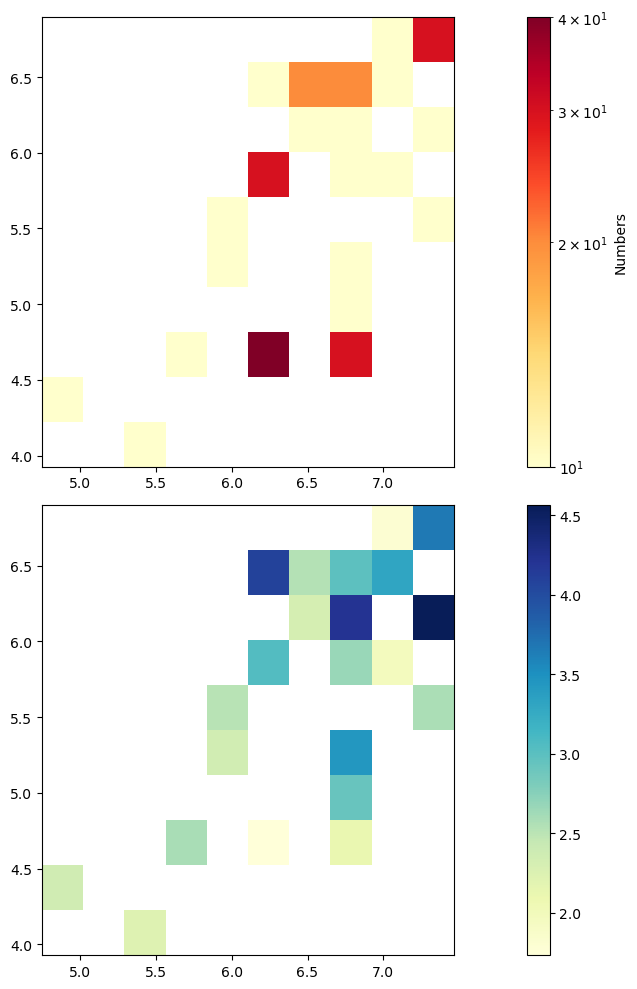

In [53]:
avg_hist(np.log10(M_1),np.log10(M_2),np.array(snr_j),bins=(10,10))

Text(0, 0.5, '$M_2$')

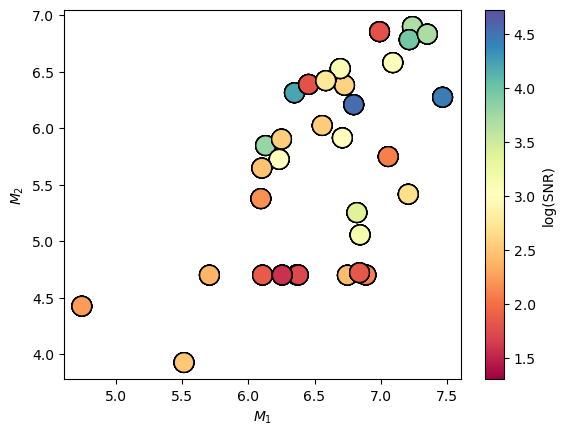

In [54]:
sc=plt.scatter(
    np.log10(M_1),  # X-axis
    np.log10(M_2),  # Y-axis
    c=np.log10(snr_j),  # Color by redshift
    cmap="Spectral",  # Choose a colormap (e.g., 'viridis', 'plasma', 'coolwarm')
    edgecolors="k", 
    alpha=1,s=200
)
cbar=plt.colorbar(sc)
cbar.set_label("log(SNR)")
plt.xlabel('$M_1$')
plt.ylabel('$M_2$')

Text(0, 0.5, '$log(SNR)$')

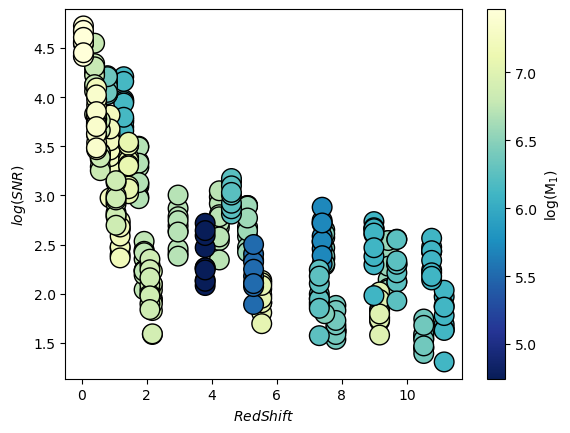

In [55]:

sc=plt.scatter(
    Z,  # X-axis
    np.log10(snr_j),  # Y-axis
    c=np.log10(M_1),  # Color by redshift
    cmap="YlGnBu_r",  # Choose a colormap (e.g., 'viridis', 'plasma', 'coolwarm')
    edgecolors="k", 
    alpha=1,s=200
)
cbar=plt.colorbar(sc)
cbar.set_label("log(M$_1$)")
plt.xlabel('$RedShift$')
plt.ylabel('$log(SNR)$')


Text(0, 0.5, '$log(SNR)$')

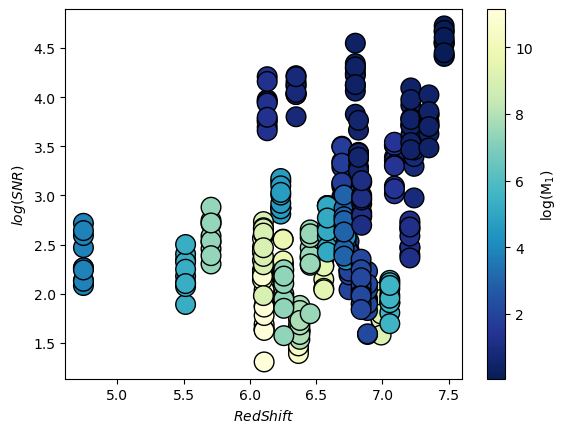

In [56]:

sc=plt.scatter(
    np.log10(M_1),  # X-axis
    np.log10(snr_j),  # Y-axis
    c=Z,  # Color by redshift
    cmap="YlGnBu_r",  # Choose a colormap (e.g., 'viridis', 'plasma', 'coolwarm')
    edgecolors="k", 
    alpha=1,s=200
)
cbar=plt.colorbar(sc)
cbar.set_label("log(M$_1$)")
plt.xlabel('$RedShift$')
plt.ylabel('$log(SNR)$')

In [57]:
snr_j

[93.43241873200766,
 44.19683951026904,
 48.75599650239697,
 75.46209047372511,
 20.252741675906208,
 42.946778225408714,
 108.60176015199144,
 42.34176721643044,
 60.009933875191784,
 73.14447915608676,
 109.85960787390043,
 225.90180452973343,
 173.5161954146269,
 279.00927315892625,
 155.50438405935685,
 171.7629210062895,
 341.3413520597947,
 270.23652062266257,
 169.56729836802796,
 261.4871452632374,
 5913.047345229177,
 9424.491246878983,
 4963.060641528512,
 5599.066295801388,
 9033.610513915375,
 16149.532616324663,
 14453.703759567383,
 4551.600140917492,
 8710.739802566535,
 6243.08931271513,
 13332.193086235347,
 10667.64720975148,
 6316.089091687952,
 14393.103013122653,
 10849.232781013821,
 10638.085537033423,
 12892.143842643782,
 16532.995552901753,
 11196.357933705769,
 16146.71295129885,
 19496.542344466812,
 13140.933331003007,
 21930.22032992149,
 11521.986252041059,
 17538.51517179827,
 16669.183543908202,
 20353.602120985586,
 13414.288347305255,
 6702.6856277173

Text(0, 0.5, 'redshift')

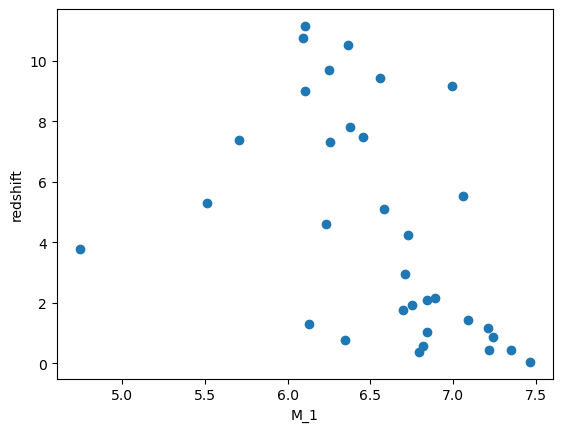

In [58]:
plt.scatter(np.log10(m1),z)
plt.xlabel('M_1')
plt.ylabel('redshift')


/tmp/ipykernel_43163/3251262282.py:21: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  y_mean.append(gmean(y[mask_x]))


([np.float64(0.05620385412015269),
  np.float64(0.07275034831195934),
  np.float64(0.09416815381017907),
  np.float64(0.121891391557225),
  np.float64(0.1577763897305028),
  np.float64(0.20422598214989351),
  np.float64(0.26435040031230467),
  np.float64(0.34217553226888564),
  np.float64(0.4429124932104189),
  np.float64(0.5733065580145442),
  np.float64(0.7420888200286877),
  np.float64(0.9605608188378675),
  np.float64(1.2433512832746971),
  np.float64(1.609395660642464),
  np.float64(2.083204020727699),
  np.float64(2.696502232548363),
  np.float64(3.490356305859269),
  np.float64(4.517922141803033),
  np.float64(5.8480048140440735),
  np.float64(7.569665707305511),
  np.float64(9.798186004011248)],
 [np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(3.8971946780202376),
  np.float64(3.43792278791093),
  np.float64(4.0743268472549214),
  np.float64(3.184170537843739),
  

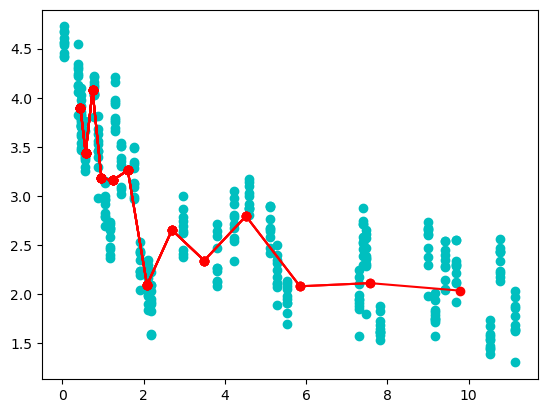

In [59]:
plt.scatter(Z,np.log10(snr_j),c='c')
x_mean_plotter( Z,np.log10(snr_j), xbins=22,color='r')

In [60]:
### Compare it with TNG

In [61]:
np.save('Z_jillian.npy',Z)

In [62]:
np.save('snr_Jillian.npy',snr_j)
np.save('M_1_jillia.npy',M_1)

# EMRIs

In [22]:
from lisatools.sources.emri import EMRITDIWaveform

In [23]:
# imports
from few.waveform import GenerateEMRIWaveform

In [77]:
gen_wave = GenerateEMRIWaveform("FastSchwarzschildEccentricFlux")

# parameters
T = 0.1  # years
dt = 10.0  # seconds
M = m1[30]
a = 0.2  # will be ignored in Schwarzschild waveform # spin for the 
mu = m2[30]
p0 = 15
e0 = 0.0
x0 = 1.0  # will be ignored in Schwarzschild waveform
qK = 0.2  # polar spin angle
phiK = 0.2  # azimuthal spin angle
qS = 0.3  # polar sky angle
phiS = 0.3  # azimuthal sky angle
dist = 1.0  # distance in G parsec
Phi_phi0 = 0.0
Phi_theta0 = 0.0
Phi_r0 = 0.0

h = gen_wave(
    M,
    mu,
    a,
    p0,
    e0,
    x0,
    dist,
    qS,
    phiS,
    qK,
    phiK,
    Phi_phi0,
    Phi_theta0,
    Phi_r0,
    T=T,
    dt=dt,
)


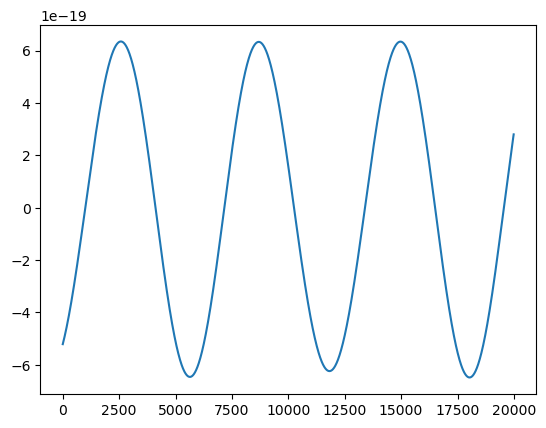

In [78]:

plt.plot(np.arange(2000) * dt, h.real[:2000])

In [79]:
### EMRI Waveforms for the data 
###
emri_lisa = EMRITDIWaveform(response_kwargs=dict(tdi_chan="AET"))

In [80]:
def EMRI_SNR(**kwargs):
    emri_lisa = EMRITDIWaveform(response_kwargs=dict(tdi_chan="AET"))
    M = kwargs["M"]
    mu = kwargs["mu"]
    a = kwargs["a"]
    p0 = kwargs["p0"]
    e0 = kwargs["e0"]
    x0 = kwargs["x0"]
    dist = kwargs["dist"]
    qS = kwargs["qS"]
    phiS = kwargs["phiS"]
    qK = kwargs["qK"]
    phiK = kwargs["phiK"]
    Phi_phi0 = kwargs["Phi_phi0"]
    Phi_theta0 = kwargs["Phi_theta0"]
    Phi_r0 = kwargs["Phi_r0"]

    SNR_new = []

    for i in range(len(M)):
        AET = emri_lisa(
        M,
        mu[i],
        a[i],
        p0[i],
        e0[i],
        x0[i],
        dist[i],
        qS[i],
        phiS[i],
        qK[i],
        phiK[i],
        Phi_phi0[i],
        Phi_theta0[i],
        Phi_r0[i],
                    )
        data = DataResidualArray(AET[0], dt=15)
        sens_mat = AET1SensitivityMatrix(data.f_arr,stochastic_params=(4.0 * YRSID_SI,))
        analysis = AnalysisContainer(data, sens_mat, signal_gen=emri_lisa)
        snr = analysis.snr()
        SNR_new.append(snr)

    return SNR_new


In [81]:
# clear (for internal clearing of answers)
 
AET = emri_lisa(
    M,
    mu,
    a,
    p0,
    e0,
    x0,
    dist,
    qS,
    phiS,
    qK,
    phiK,
    Phi_phi0,
    Phi_theta0,
    Phi_r0,)

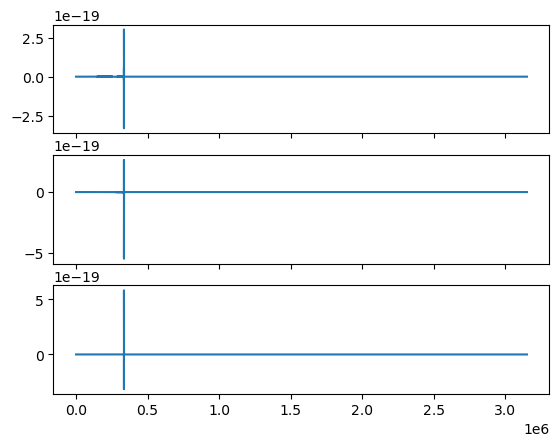

In [82]:
fig, ax = plt.subplots(3, 1, sharex=True)

for i in range(3):
    ax[i].plot(AET[i])

In [83]:
data = DataResidualArray(AET, dt=dt)

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

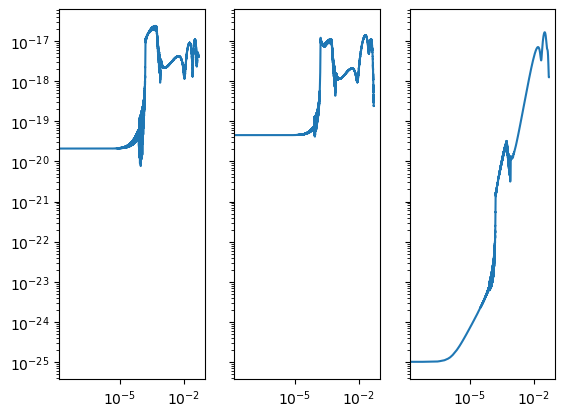

In [84]:
data.loglog()

In [26]:
### T Channel

In [53]:
from lisatools.sensitivity import SensitivityMatrix, A1TDISens, E1TDISens, AET1SensitivityMatrix

In [54]:
# sens_mat = SensitivityMatrix(data.f_arr, [AET1SensitivityMatrix])

In [55]:
data.f_arr

array([0.00000000e+00, 3.17479064e-08, 6.34958128e-08, ...,
       4.99999365e-02, 4.99999683e-02, 5.00000000e-02], shape=(1574908,))

In [85]:
# data = DataResidualArray(AET[0], f_arr=freqs)
sens_mat = AET1SensitivityMatrix(data.f_arr,stochastic_params=(4.0 * YRSID_SI,))
analysis = AnalysisContainer(data, sens_mat, signal_gen=emri_lisa)
snr = analysis.snr()
        

/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:633: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:635: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:637: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:642: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:644: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi * frq 

In [86]:
snr

763.0416353914223

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

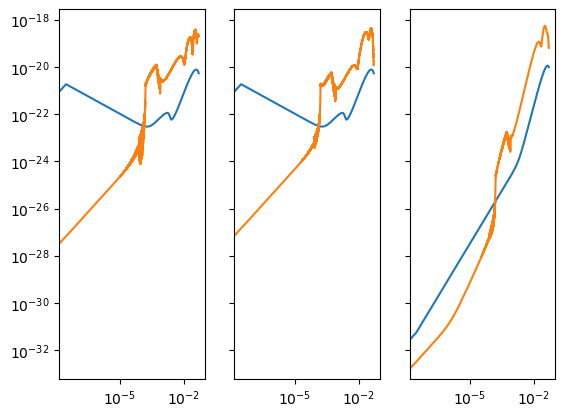

In [87]:
analysis.loglog()

## EMRI Functions

In [24]:
emri_lisa = EMRITDIWaveform(response_kwargs=dict(tdi_chan="AET"))

In [25]:
def EMRI_SNR(**kwargs):
    emri_lisa = EMRITDIWaveform(response_kwargs=dict(tdi_chan="AET"))

    # Extract parameters from kwargs
    M = kwargs["M"]
    mu = kwargs["mu"]
    a = kwargs["a"]
    p0 = kwargs["p0"]
    e0 = kwargs["e0"]
    x0 = kwargs["x0"]
    dist = kwargs["dist"]
    qS = kwargs["qS"]
    phiS = kwargs["phiS"]
    qK = kwargs["qK"]
    phiK = kwargs["phiK"]
    Phi_phi0 = kwargs["Phi_phi0"]
    Phi_theta0 = kwargs["Phi_theta0"]
    Phi_r0 = kwargs["Phi_r0"]

    SNR_new = []

    for i in range(len(M)):  # Ensure this correctly matches `arr_size`:
        AET = emri_lisa(
            M[i],          
            mu[i],         
            a[i],
            p0[i],
            e0[i],   
            x0[i],
            dist[i],
            qS[i],
            phiS[i],
            qK[i],
            phiK[i],
            Phi_phi0[i],
            Phi_theta0[i],
            Phi_r0[i],
        )

        data = DataResidualArray(AET, dt=15)
        sens_mat = AET1SensitivityMatrix(data.f_arr, stochastic_params=(4.0 * YRSID_SI,))
        analysis = AnalysisContainer(data, sens_mat, signal_gen=emri_lisa)
        snr = analysis.snr()
        SNR_new.append(snr)

    return SNR_new

In [26]:
def emri_params(mu=m2, M=m1, dist=d_l,T=.1,n=1,p0=7): 
                
    arr_size=len(M)*n

    
    result = {
    'T': np.full(arr_size, T),  # years
    'dt': np.full(arr_size, 10),  # seconds
    'M': np.array(list(chain.from_iterable(repeat(x, n) for x in M))),
    'a': np.full(arr_size, 0.1),  # ignored in Schwarzschild waveform
    'mu': np.array(list(chain.from_iterable(repeat(x, n) for x in mu))),
    'p0': np.full(arr_size, p0),
    'e0': np.full(arr_size, 0.2),
    'x0': uniform_dist(-1, 1).rvs(arr_size),  # ignored in Schwarzschild waveform
    'qK': uniform_dist(0.0, np.pi).rvs(arr_size),  # polar spin angle
    'phiK': uniform_dist(0.0, 2 * np.pi).rvs(arr_size),  # azimuthal spin angle
    'qS': uniform_dist(0.0, np.pi).rvs(arr_size),  # polar sky angle
    'phiS': uniform_dist(0.0, 2 * np.pi).rvs(arr_size),  # azimuthal sky angle
    'dist': np.array(list(chain.from_iterable(repeat(x, n) for x in dist))),
    'Phi_phi0': np.full(arr_size, 1),
    'Phi_theta0': np.full(arr_size, 2),
    'Phi_r0': np.full(arr_size, 3)
}
    return result

In [46]:
def emri_waveform(**kwargs):
    M = kwargs["M"].item()
    mu = kwargs["mu"].item()
    a = kwargs["a"].item()
    p0 = kwargs["p0"].item()
    e0 = kwargs["e0"].item()
    x0 = kwargs["x0"].item()
    dist = kwargs["dist"].item()
    qS = kwargs["qS"].item()
    phiS = kwargs["phiS"].item()
    qK = kwargs["qK"].item()
    phiK = kwargs["phiK"].item()
    Phi_phi0 = kwargs["Phi_phi0"].item()
    Phi_theta0 = kwargs["Phi_theta0"].item()
    Phi_r0 = kwargs["Phi_r0"].item()
    AET = emri_lisa(
                    M,
                    mu,
                    a,
                    p0,
                    e0,
                    x0,
                    dist,
                    qS,
                    phiS,
                    qK,
                    phiK,
                    Phi_phi0,
                    Phi_theta0,
                    Phi_r0,
                            )
   
    fig, ax = plt.subplots(3, 1, sharex=True)
     
    for i in range(3):
               ax[i].plot(AET[i])
    return

## Analysis

In [ ]:
# get the distance in GPC
# BISECTION SEARCH FOR p0

In [ ]:
em1 = emri_params(mu=[m2[30]], M=[m1[30]], p0=8, n=1, dist=[d_l[30]])

In [ ]:
EMRI_SNR(**em1)

[3.230348250834596e-24,
 2.219506625252015e-24,
 1.2205652900456058e-24,
 9.520964647465162e-25,
 2.1306781984663025e-24,
 2.7604444950740093e-24,
 2.352079746416167e-24,
 1.6505109014516672e-24,
 2.054339609317145e-24,
 2.122057102920617e-24]

/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/few/utils/baseclasses.py:416: UserWarning: Mass ratio is outside of generally accepted range for an extreme mass ratio (1e-4). (q=0.00762192)
  warnings.warn(


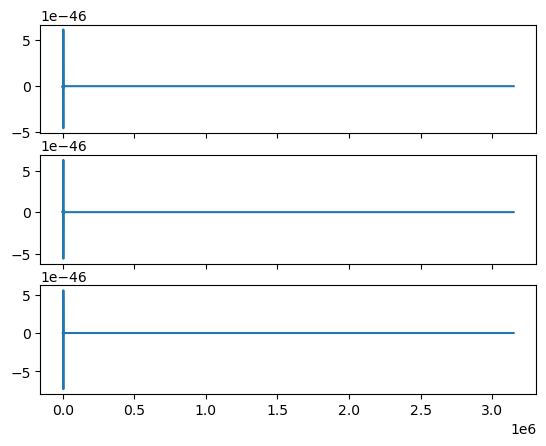

In [ ]:
emri_waveform(**em1)

/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/few/utils/baseclasses.py:416: UserWarning: Mass ratio is outside of generally accepted range for an extreme mass ratio (1e-4). (q=0.00894852)
  warnings.warn(


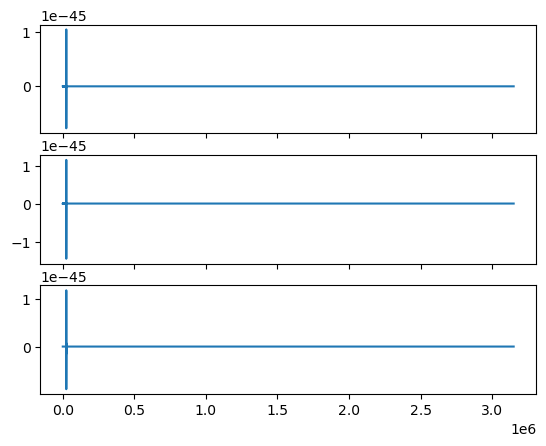

In [88]:
em2 = emri_params(mu=[m2[1]], M=[m1[1]], p0=10, n=1, dist=[d_l[1]])
emri_waveform(**em2)